## NB1

The goal of this notebook is to explore the Online Retail transactional dataset, understand customer purchasing behavior, and prepare the data for churn definition and feature engineering.

## 1.Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 2. Load Dataset

In [3]:
df = pd.read_excel("C:/Projects/09_Customer_churn_predictor/data/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 3.Data Inspection

In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 4. Data Cleaning

In [7]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
# Handle missing Values
df = df.dropna(subset=['CustomerID'])

In [9]:
# Handle missing values
df = df.dropna(subset=['Description'])

In [12]:
# Remove Negative value
df = df[df["Quantity"]> 0]
df = df[df["UnitPrice"]> 0]

In [13]:
# Convert Date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [14]:
# Create total price
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

- Removed missing CustomerID as it is essential for customer-level analysis
- Removed negative values to eliminate returns or errors
- Created TotalPrice for revenue analysis

# 5. Univariate Analysis


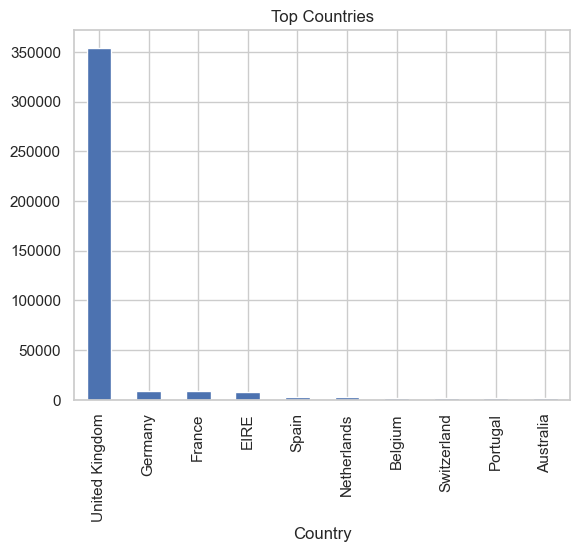

In [15]:
# Top countries
df['Country'].value_counts().head(10).plot(kind="bar")
plt.title("Top Countries")
plt.show()

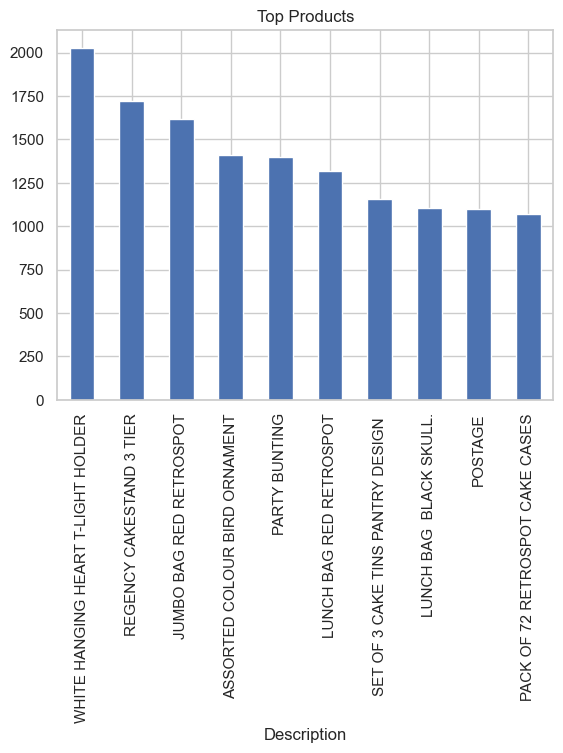

In [16]:
# Top products
df['Description'].value_counts().head(10).plot(kind="bar")
plt.title("Top Products")
plt.show()

## 6. Time analysis

C:\Users\shwey\AppData\Local\Temp\ipykernel_40300\98313072.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index("InvoiceDate").resample("M")["InvoiceNo"].count().plot()


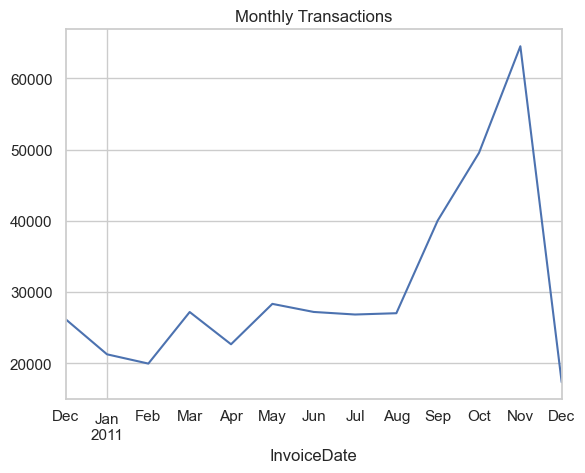

In [17]:
df.set_index("InvoiceDate").resample("M")["InvoiceNo"].count().plot()
plt.title("Monthly Transactions")
plt.show()

## 7. Customer Level Aggregation

In [20]:
customer_df = df.groupby("CustomerID").agg({
    "InvoiceNo": "nunique",
    "Quantity": "sum",
    "TotalPrice": "sum",
    "InvoiceDate": "max"
})

customer_df.columns = ["Frequency", "TotalQuantity", "Monetary", "LastPurchase"]

## 8. Create Recency

In [21]:
reference_date = df['InvoiceDate'].max()
customer_df['Recency'] = (reference_date - customer_df["LastPurchase"]).dt.days

## 9. RFM Distributions

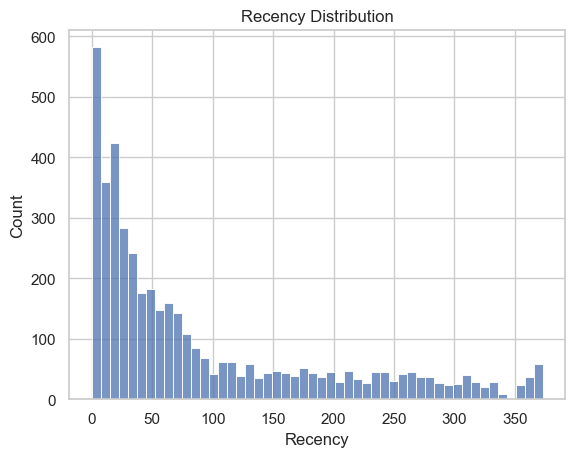

In [ ]:
# Recency
sns.histplot(customer_df["Recency"], bins=50)
plt.title("Recency Distribution")
plt.show()

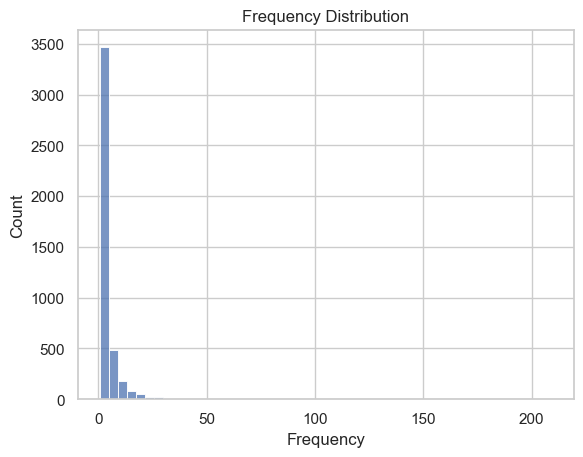

In [23]:
# Frequency
sns.histplot(customer_df["Frequency"], bins=50)
plt.title("Frequency Distribution")
plt.show()

<Axes: xlabel='Frequency', ylabel='Count'>

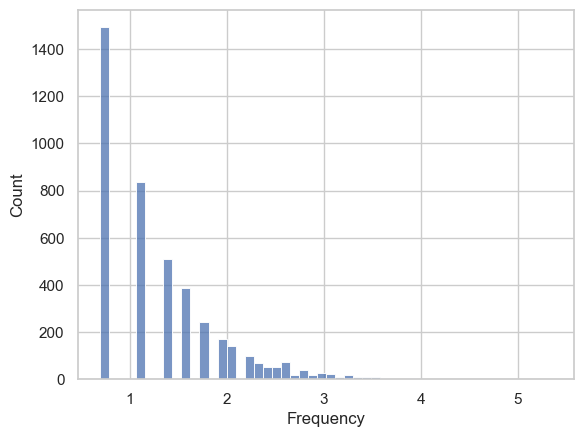

In [25]:
# Frequency(Log)
sns.histplot(np.log1p(customer_df['Frequency']), bins=50)

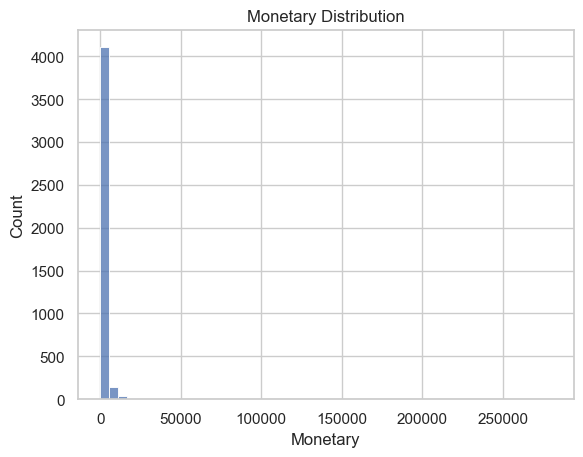

In [24]:
# Monetary
sns.histplot(customer_df["Monetary"], bins=50)
plt.title("Monetary Distribution")
plt.show()

<Axes: xlabel='Monetary', ylabel='Count'>

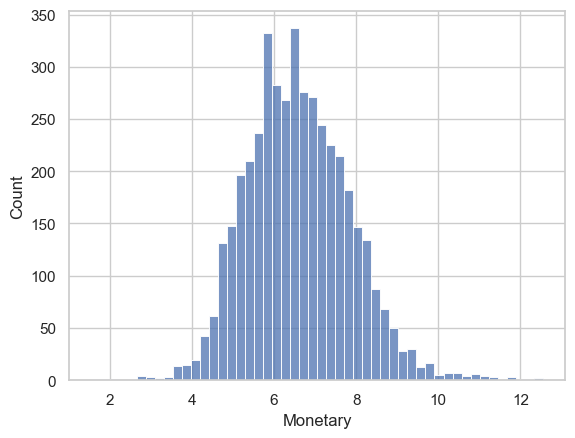

In [26]:
# Monetary(log)
sns.histplot(np.log1p(customer_df["Monetary"]), bins=50)

“Log transformation was applied to highly skewed features like Frequency and Monetary to reduce the impact of extreme values and improve interpretability.”

## 10. Save the dataset

In [28]:
customer_df.to_csv("C:/Projects/09_Customer_churn_predictor/data/customer_features.csv", index=True)